In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [24]:
df = pd.read_csv('IoTPond2.csv')
df.head()

,created_at,entry_id,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length (cm),Fish_Weight (g)
0,2021-06-19 00:00:05 CET,1889,24.8750,100,4.505,8.43365,0.38,193,50,6.96,3.36
1,2021-06-19 00:01:02 CET,1890,24.9375,100,6.601,8.43818,0.38,194,50,6.96,3.36
2,2021-06-19 00:01:22 CET,1891,24.8750,100,15.797,8.42457,0.38,192,50,6.96,3.36
3,2021-06-19 00:01:44 CET,1892,24.9375,100,5.046,8.43365,0.38,193,50,6.96,3.36
4,2021-06-19 00:02:07 CET,1893,24.9375,100,38.407,8.40641,0.38,192,50,6.96,3.36


In [25]:
print(df.isnull().sum())

created_at                 0
entry_id                   0
Temperature (C)            0
Turbidity (NTU)            0
Dissolved Oxygen(g/ml)     0
PH                         0
Ammonia(g/ml)             90
Nitrate(g/ml)              0
Population                 0
Fish_Length (cm)           0
Fish_Weight (g)            0
dtype: int64


In [26]:
df.describe()

,entry_id,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length (cm),Fish_Weight (g)
count,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,1.721590e+05,172249.000000,172249.0,172249.000000,172249.000000
mean,148725.739702,24.982849,90.974665,9.708503,3.971857,3.112110e+08,719.891448,50.0,23.428782,166.470532
std,85418.776568,0.901890,21.099910,10.971962,3.960719,1.257809e+10,415.979780,0.0,9.609826,145.752669
min,1889.000000,-127.000000,1.000000,0.007000,-3.137450,6.590000e-03,45.000000,50.0,6.960000,3.360000
25%,62717.000000,24.375000,94.000000,3.200000,-0.173180,5.693500e-01,189.000000,50.0,14.220000,22.890000
50%,147763.000000,24.937500,100.000000,3.283000,7.099040,8.470560e+00,890.000000,50.0,20.970000,65.480000
75%,226310.000000,25.500000,100.000000,11.739000,7.516670,8.070516e+01,1050.000000,50.0,32.540000,302.500000
max,269372.000000,27.812500,100.000000,41.046000,8.551670,9.965130e+11,2224.000000,50.0,35.390000,394.660000


In [27]:
df.shape

(172249, 11)

In [28]:
df['Ammonia(g/ml)'].fillna(df['Ammonia(g/ml)'].mean(), inplace=True)

In [29]:
print(df.isnull().sum())

created_at                0
entry_id                  0
Temperature (C)           0
Turbidity (NTU)           0
Dissolved Oxygen(g/ml)    0
PH                        0
Ammonia(g/ml)             0
Nitrate(g/ml)             0
Population                0
Fish_Length (cm)          0
Fish_Weight (g)           0
dtype: int64


In [31]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [32]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [33]:
df.head()

,created_at,entry_id,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length (cm),Fish_Weight (g),Date,month,year,hour,minutes,seconds
0,2021-06-19 00:00:05+00:00,1889,24.8750,100,4.505,8.43365,0.38,193,50,6.96,3.36,19,6,2021,0,0,5
1,2021-06-19 00:01:02+00:00,1890,24.9375,100,6.601,8.43818,0.38,194,50,6.96,3.36,19,6,2021,0,1,2
2,2021-06-19 00:01:22+00:00,1891,24.8750,100,15.797,8.42457,0.38,192,50,6.96,3.36,19,6,2021,0,1,22
3,2021-06-19 00:01:44+00:00,1892,24.9375,100,5.046,8.43365,0.38,193,50,6.96,3.36,19,6,2021,0,1,44
4,2021-06-19 00:02:07+00:00,1893,24.9375,100,38.407,8.40641,0.38,192,50,6.96,3.36,19,6,2021,0,2,7


In [34]:
df.drop(["created_at"], axis = 1, inplace = True)

In [35]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [36]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [37]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [38]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [39]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [40]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [41]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e9, inplace=True)

In [42]:
for i in range(len(df)):
    if df.loc[i, "Temperature (C)"] < 20 or df.loc[i, "Temperature (C)"] > 30:
        df.loc[i, "Temperature (C)"] = df.loc[i-1, "Temperature (C)"]

In [43]:
for i in range(1,len(df)):
    if df.loc[i, "PH"] < 6 or df.loc[i, "PH"] > 8.5:
        df.loc[i, "PH"] = df.loc[i-1,'PH']

In [44]:
df.at[0, 'Dissolved Oxygen(g/ml)'] = 5

In [45]:
for i in range(1,len(df)):
    if df.loc[i, "Dissolved Oxygen(g/ml)"] < 5 or df.loc[i, "Dissolved Oxygen(g/ml)"] > 20:
        df.loc[i, "Dissolved Oxygen(g/ml)"] = df.loc[i-1, "Dissolved Oxygen(g/ml)"]

In [46]:
df.describe()

,entry_id,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length (cm),Fish_Weight (g),Date,month,year,hour,minutes,seconds
count,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,1.722490e+05,172249.000000,172249.0,172249.000000,172249.000000,172249.000000,172249.000000,172249.0,172249.000000,172249.000000,172249.000000
mean,148725.739702,24.983728,90.974665,8.899058,7.166010,3.112110e+08,719.891448,50.0,23.428782,166.470532,16.606703,8.299450,2021.0,11.464276,29.492839,29.478186
std,85418.776568,0.824200,21.099910,4.803473,0.542108,1.257480e+10,415.979780,0.0,9.609826,145.752669,9.985388,1.394712,0.0,6.864468,17.332834,17.310293
min,1889.000000,23.000000,1.000000,5.000000,6.000490,6.590000e-03,45.000000,50.0,6.960000,3.360000,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000
25%,62717.000000,24.375000,94.000000,5.034000,6.849370,5.693500e-01,189.000000,50.0,14.220000,22.890000,8.000000,7.000000,2021.0,5.000000,14.000000,14.000000
50%,147763.000000,24.937500,100.000000,6.322000,7.099040,8.475800e+00,890.000000,50.0,20.970000,65.480000,18.000000,8.000000,2021.0,12.000000,29.000000,29.000000
75%,226310.000000,25.500000,100.000000,11.909000,7.516670,8.105899e+01,1050.000000,50.0,32.540000,302.500000,26.000000,10.000000,2021.0,17.000000,45.000000,44.000000
max,269372.000000,27.812500,100.000000,19.998000,8.492660,9.965130e+11,2224.000000,50.0,35.390000,394.660000,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000


In [47]:
df["Ammonia(g/ml)"] = np.log(df["Ammonia(g/ml)"]) / 10.0
df["Ammonia(g/ml)"] = df["Ammonia(g/ml)"].abs()


In [48]:
df["Nitrate(g/ml)"] = df["Nitrate(g/ml)"].apply(np.sqrt)

In [49]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [50]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [51]:
df.head()

,Date,month,year,hour,minutes,seconds,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length (cm),Fish_Weight (g)
0,19,6,2021,0,0,5,24.8750,100,5.000,8.43365,0.096758,13.892444,6.96,3.36
1,19,6,2021,0,1,2,24.9375,100,6.601,8.43818,0.096758,13.928388,6.96,3.36
2,19,6,2021,0,1,22,24.8750,100,15.797,8.42457,0.096758,13.856406,6.96,3.36
3,19,6,2021,0,1,44,24.9375,100,5.046,8.43365,0.096758,13.892444,6.96,3.36
4,19,6,2021,0,2,7,24.9375,100,5.046,8.40641,0.096758,13.856406,6.96,3.36


In [52]:
df.describe()

,Date,month,year,hour,minutes,seconds,Temperature (C),Turbidity (NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length (cm),Fish_Weight (g)
count,172249.000000,172249.000000,172249.0,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000,172249.000000
mean,16.606703,8.299450,2021.0,11.464276,29.492839,29.478186,24.983728,90.974665,8.899058,7.166010,0.359717,25.261542,23.428782,166.470532
std,9.985388,1.394712,0.0,6.864468,17.332834,17.310293,0.824200,21.099910,4.803473,0.542108,0.392324,9.041372,9.609826,145.752669
min,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000,23.000000,1.000000,5.000000,6.000490,0.000036,6.708204,6.960000,3.360000
25%,8.000000,7.000000,2021.0,5.000000,14.000000,14.000000,24.375000,94.000000,5.034000,6.849370,0.096758,13.747727,14.220000,22.890000
50%,18.000000,8.000000,2021.0,12.000000,29.000000,29.000000,24.937500,100.000000,6.322000,7.099040,0.216670,29.832868,20.970000,65.480000
75%,26.000000,10.000000,2021.0,17.000000,45.000000,44.000000,25.500000,100.000000,11.909000,7.516670,0.439920,32.403703,32.540000,302.500000
max,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000,27.812500,100.000000,19.998000,8.492660,2.762753,47.159304,35.390000,394.660000


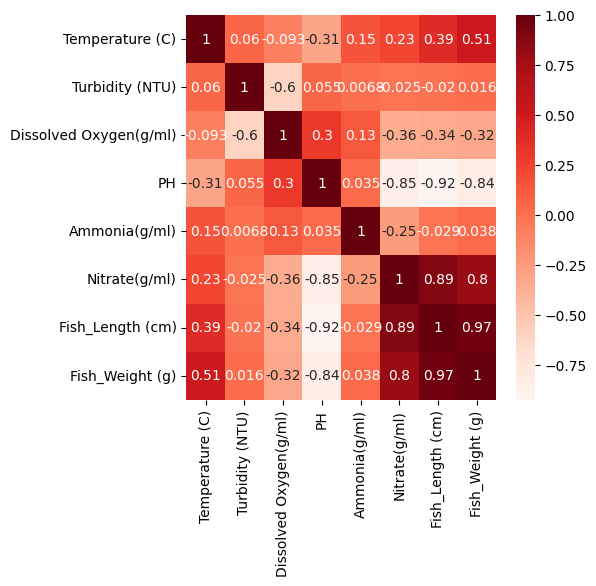

In [54]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [55]:
df.to_csv('pp2.csv', index=False)